#Name: Raul Dmonty
##Batch: A1 Rollno: 18

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

#Part 1 Data

In [ ]:
def fetch_indicator(code, year = "2022"):
  url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=3000"
  response = requests.get(url).json()[1]

  data = {}
  for item in response:
    country = item["country"] ["value"]
    value = item["value"]
    if value  is not None:
      data[country] = value
  return pd.Series(data, name = code)

In [ ]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [ ]:
df = pd.concat([gdp, pop, life, lit], axis = 1)
df.columns = ["GDP", "Population", "LifeExpectancy", "Literacy"]
df.dropna(inplace = True)

In [ ]:
scalar = StandardScaler()
df_scaled = scalar.fit_transform(df)

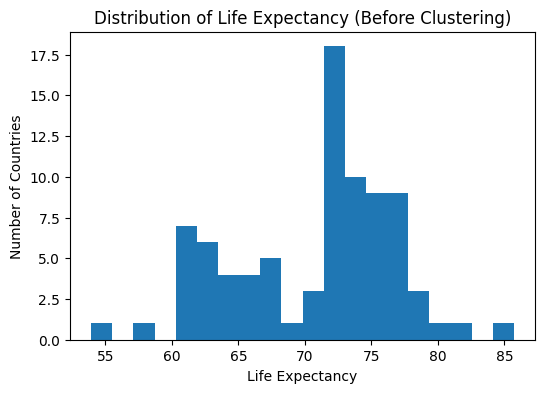

In [ ]:
plt.figure(figsize = (6, 4))
plt.hist(df["LifeExpectancy"], bins = 20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Countries")
plt.title("Distribution of Life Expectancy (Before Clustering)")
plt.show()

#Part 2

k	WCSS
1 	 336.00000000000006
2 	 210.63753562846534
3 	 140.4473799215995
4 	 116.65471927455161
5 	 65.7775830436284
6 	 59.151622717303624
7 	 49.0340735899651
8 	 42.91467281060775
9 	 36.95330621833097
10 	 29.767798732782307


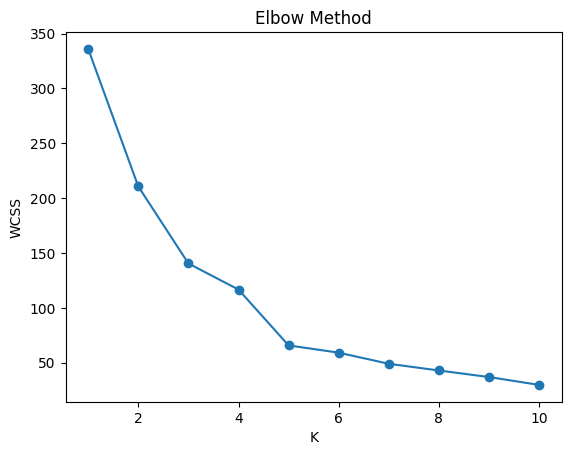

In [ ]:
wcss= []
for k in range(1, 11):
  km = KMeans(n_clusters = k, random_state = 42)
  km.fit(df_scaled)
  wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
  print(i+1, "\t", wcss[i])

plt.plot(range(1, 11), wcss, marker = "o")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

#Part 3

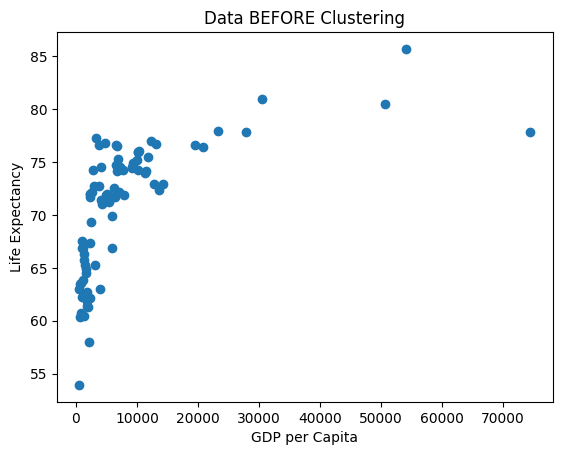

In [ ]:
plt.scatter(df["GDP"], df["LifeExpectancy"])
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("Data BEFORE Clustering")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 42)
labels_km = kmeans.fit_predict(df_scaled)
df["KMeansCluster"] = labels_km

In [ ]:
hc = AgglomerativeClustering(n_clusters = 3)
labels_hc = hc.fit_predict(df_scaled)
df["HierarchicalCluster"] = labels_hc

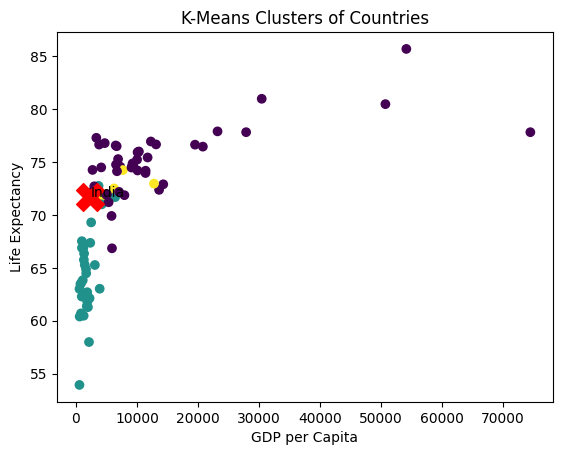

In [ ]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c = labels_km)
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters of Countries")
india = df.loc["India"]
plt.scatter(india["GDP"], india["LifeExpectancy"], s = 400, color= 'Red', marker= "X")
plt.text(india["GDP"], india["LifeExpectancy"], "India")
plt.show()

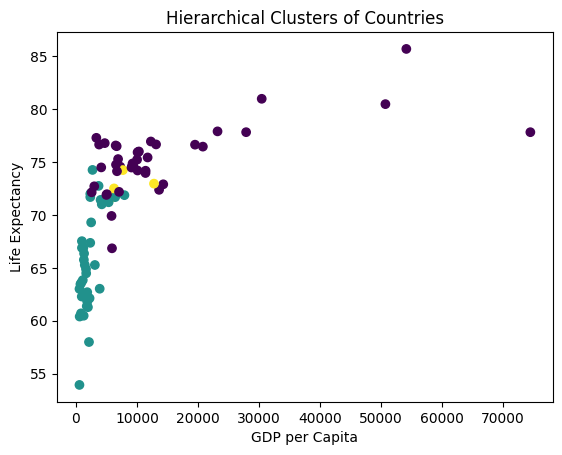

In [ ]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c = labels_hc)
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchical Clusters of Countries")
plt.show()

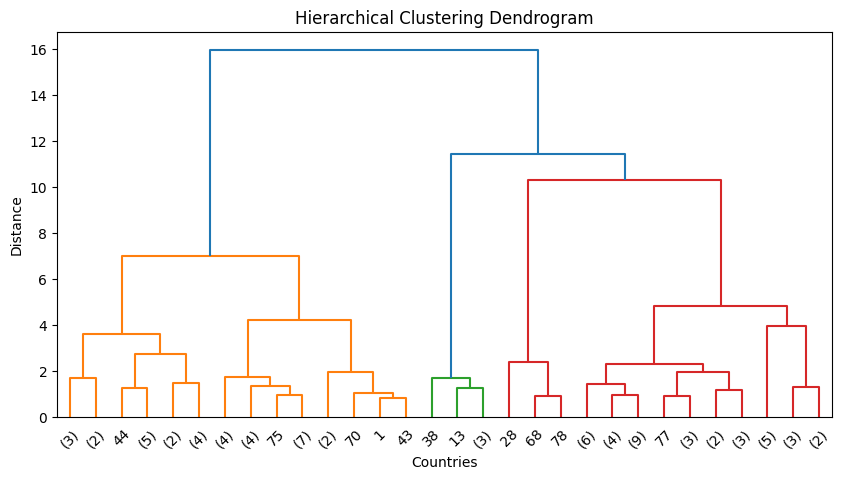

In [ ]:
linked = linkage(df_scaled, method = "ward")
plt.figure(figsize = (10,5))
dendrogram(linked, truncate_mode= 'lastp', p = 30)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()

In [ ]:
def country(country_name):
  result = df.loc[country_name]
  print("\nCountry: ", country_name)
  print("GDP per Capita: ", result["GDP"])
  print("Population: ", result["Population"])
  print("Life Expectancy: ", result["LifeExpectancy"])
  print("Literacy Rate: ", result["Literacy"])
  print("K-Means Cluster: ", result["KMeansCluster"])
  print("Hierarchical Cluster: ", result["HierarchicalCluster"])

In [ ]:
country("India")
country("North America")
country("Brazil")
country("Viet Nam")
country("Bahrain")


Country:  India
GDP per Capita:  2347.44829434623
Population:  1425423212.0
Life Expectancy:  71.698
Literacy Rate:  76.3199996948242
K-Means Cluster:  1.0
Hierarchical Cluster:  1.0

Country:  North America
GDP per Capita:  74535.6365392629
Population:  373018004.0
Life Expectancy:  77.8327679594239
Literacy Rate:  98.7891464233398
K-Means Cluster:  0.0
Hierarchical Cluster:  0.0

Country:  Brazil
GDP per Capita:  9281.33282136864
Population:  210306415.0
Life Expectancy:  74.872
Literacy Rate:  94.3853874531348
K-Means Cluster:  0.0
Hierarchical Cluster:  0.0

Country:  Viet Nam
GDP per Capita:  4147.69777213621
Population:  99680655.0
Life Expectancy:  74.502
Literacy Rate:  96.129997253418
K-Means Cluster:  0.0
Hierarchical Cluster:  0.0

Country:  Bahrain
GDP per Capita:  30470.5219276023
Population:  1524693.0
Life Expectancy:  80.992
Literacy Rate:  97.870002746582
K-Means Cluster:  0.0
Hierarchical Cluster:  0.0


In [ ]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0              13280.490845  3.923248e+08       75.101970  94.739797
1               1915.596661  6.544831e+08       64.856833  68.564031
2               7094.638897  5.911254e+09       72.421619  86.116721
